#Imports and Collatz Function

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style = "whitegrid", palette = "pastel", font_scale = 1.2)

# Basic Collatz sequence (returns full sequence, ending at 1)
def collatz_sequence(n):
    seq = [n]
    while n != 1:
        if n % 2 == 0:
            n //= 2
        else:
            n = 3*n + 1
        seq.append(n)
    return seq

def collatz_steps(n):
    return len(collatz_sequence(n)) - 1

2. Part (A):
The collatz conjecture was implemented using two functions, collatz_sequence and collatz_steps. The first returns an array of each value in the sequence, while the second returns the length of the sequence. Collatz_sequence was optimized through recursion and memoization, with each values subsequent sequence being saved in a dictionary which will limit further calculations.

#Collatz Sequence Lengths 1-10.000

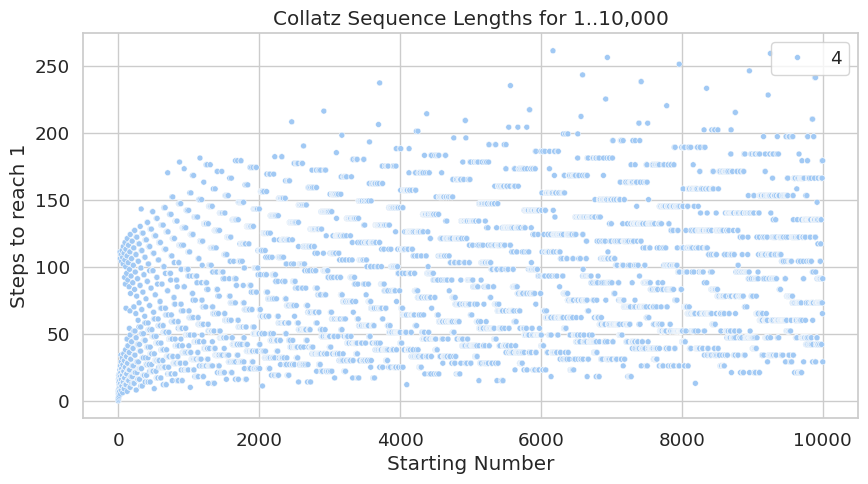

In [ ]:
numbers = np.arange(1, 10001)
lengths = np.array([collatz_steps(int(n)) for n in numbers])

plt.figure(figsize = (10,5))
sns.scatterplot(x=numbers, y=lengths, size=4)
plt.title("Collatz Sequence Lengths for 1..10,000")
plt.xlabel("Starting Number")
plt.ylabel("Steps to reach 1")
plt.show()

2. Part (B):
This code compiles an array of the sequence length's of each number from 1-10000. This data is then displayed on a scatter plot, with the independent variable being the number n and the dependent variable being the length, also known as the number of steps.

#Data Visualization

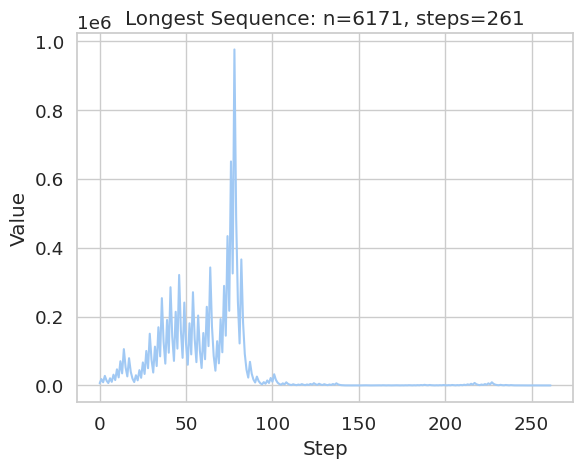

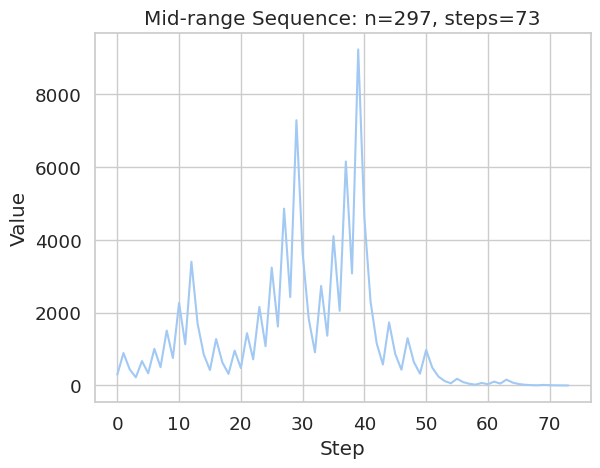

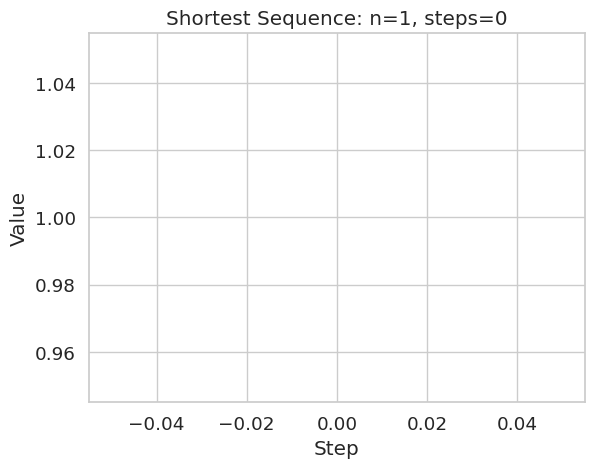

In [ ]:
# Identify interesting sequences:
longest_n = int(numbers[np.argmax(lengths)])
shortest_n = int(numbers[np.argmin(lengths)])
median_len = int(np.median(lengths))
midrange_n = int(numbers[np.argmin(np.abs(lengths - median_len))])


def plot_sequence(n, title):
  seq = collatz_sequence(n)
  x = list(range(len(seq)))
  plt.figure()
  plt.plot(x, seq)
  plt.title(f"{title}: n={n}, steps={len(seq)-1}")
  plt.xlabel("Step")
  plt.ylabel("Value")
  plt.show()

# Plot the interesting sequences
plot_sequence(longest_n, "Longest Sequence")
plot_sequence(midrange_n, "Mid-range Sequence")
plot_sequence(shortest_n, "Shortest Sequence")

2. Part (C): Three interesting sequences, the longest, mid-range, and shortest, are displayed through three graphs. The longest sequence is identified as originating with the number n = 6171 and the number of steps = 261. The mid-range sequence is identified as originating with the number n = 296 and the number of steps = 73. The shortest sequence is identified as originating with the number n = 1 and the number of steps = 0, which makes a lot of sense!

# Data Set Creation

      Number  Sequence Length  Final Halfway Point  Max Value in Sequence  \
0          1                0                    1                      1   
1          2                1                    1                      2   
2          3                7                    8                     16   
3          4                2                    2                      4   
4          5                5                    4                     16   
...      ...              ...                  ...                    ...   
9995    9996              179                83501                 250504   
9996    9997              179                83501                 250504   
9997    9998               91                 2429                  33748   
9998    9999               91                 2429                 101248   
9999   10000               29                   11                  10000   

      Mean Value in Sequence  
0                   1.000000  
1            

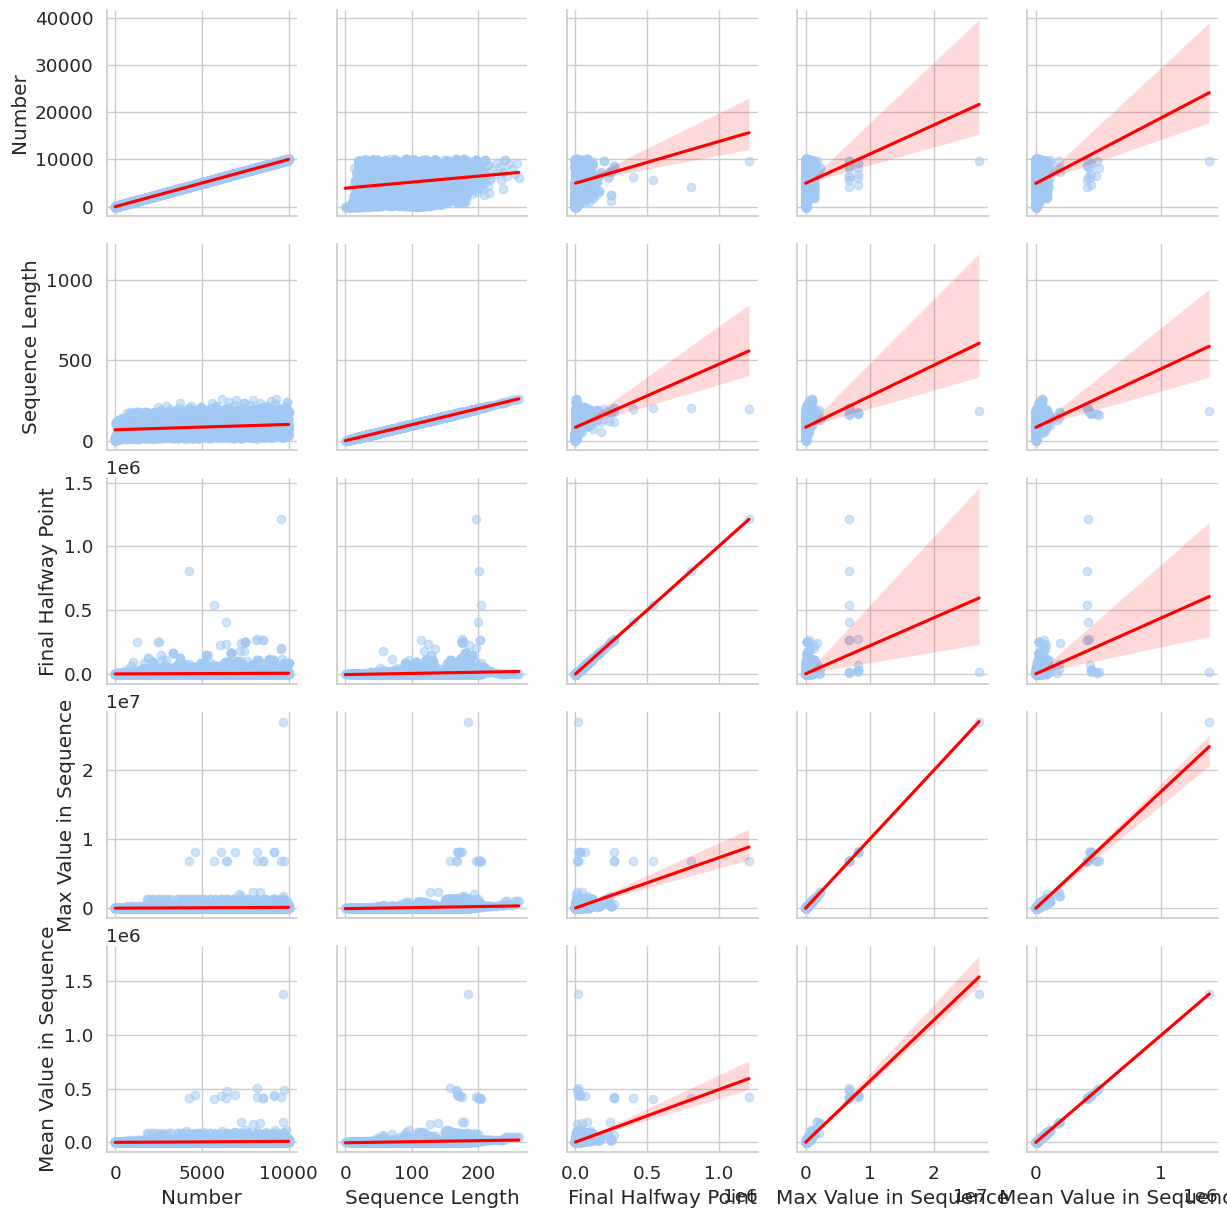

In [ ]:
def sequence_stats(n):
    seq = collatz_sequence(n)
    steps = len(seq) - 1
    halfway_value = seq[len(seq)//2]
    max_value = max(seq)
    mean_value = float(np.mean(seq))
    return steps, halfway_value, max_value, mean_value

rows = []
for n in numbers:
    steps, half_val, max_val, mean_val = sequence_stats(n)
    rows.append((int(n), int(steps), int(half_val), int(max_val), mean_val))

df = pd.DataFrame(rows, columns=[
    "Number",
    "Sequence Length",
    "Final Halfway Point",
    "Max Value in Sequence",
    "Mean Value in Sequence"
])


#Visualize column correlations using PairGrid
g = sns.PairGrid(df, vars=["Number", "Sequence Length", "Final Halfway Point", "Max Value in Sequence","Mean Value in Sequence"])
g.map(sns.regplot, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})

# Save to a csv file
df.to_csv("collatz_sequences_data.csv", index=False)
print(df)

2. Part (D): This code creates a pandas data frame that includes several significant columns related to each collatz sequence from numbers 1-10000. The columns include Number, Sequence Length, Final Halfway Point, Max Value in Sequence, Mean Value in Sequence.

# Reflection

In this project we worked with the Collatz Conjecture.
We built a function that makes the Collatz sequence and counts the steps until it reaches 1.
We ran this for every number from 1 to 10,000 and saved the results in a dataset with extra stats
(sequence length, halfway value, maximum value, and average value).
We also created a scatter plot of all numbers (x-axis) and sequence lengths (y-axis) and line graphs for three sequence examples.
(longest, shortest, and a mid-range sequence).

Observations:
1. Some numbers take hundreds of steps, while others drop to 1 very quickly.
   This shows how unpredictable the sequence lengths are.

2. Long sequences often shoot up to very high values before slowly falling back down.
   Short ones usually hit a power of two and then quickly fall to 1.

3. The scatter plot shows “bands” or layers, which suggests that many numbers share parts of the same paths.